# M2_02 — Feature analysis por feature set

Objetivo:
- Visualizar calidad y comportamiento de features.
- Facilitar comparación entre feature sets (`base/tech/macro/sent/full`).

Inputs:
- `../data/btc_1d_features__<feature_set>.csv`

Outputs:
- Figuras PNG en `../data/_figures/feature_analysis/`
- Resumen CSV en `../data/_reports/feature_analysis__summary.csv`


In [1]:
import sys
import subprocess
import importlib
import pathlib

for p in ["pandas", "numpy", "matplotlib", "scikit-learn"]:
    try:
        importlib.import_module(p if p != "scikit-learn" else "sklearn")
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", p])

try:
    importlib.import_module("seaborn")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression


In [2]:
base_dir = pathlib.Path(".").resolve()
data_dir = (base_dir.parent / "data").resolve()
fig_dir = (data_dir / "_figures" / "feature_analysis").resolve()
reports_dir = (data_dir / "_reports").resolve()
fig_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

FEATURE_SETS = ["base", "tech", "macro", "sent", "full"]
FEATURE_SET = "tech"

DATA_PATH = data_dir / f"btc_1d_features__{FEATURE_SET}.csv"
SUMMARY_PATH = reports_dir / "feature_analysis__summary.csv"

(DATA_PATH.as_posix(), fig_dir.as_posix())

('/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/proyecto_grado/data/btc_1d_features__tech.csv',
 '/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/proyecto_grado/data/_figures/feature_analysis')

In [3]:
def load_dataset(path: pathlib.Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df = df.sort_values("timestamp").reset_index(drop=True)
    return df


df = load_dataset(DATA_PATH)
df.shape, df["timestamp"].min().isoformat(), df["timestamp"].max().isoformat()

((4052, 34), '2015-02-10T00:00:00+00:00', '2026-03-15T00:00:00+00:00')

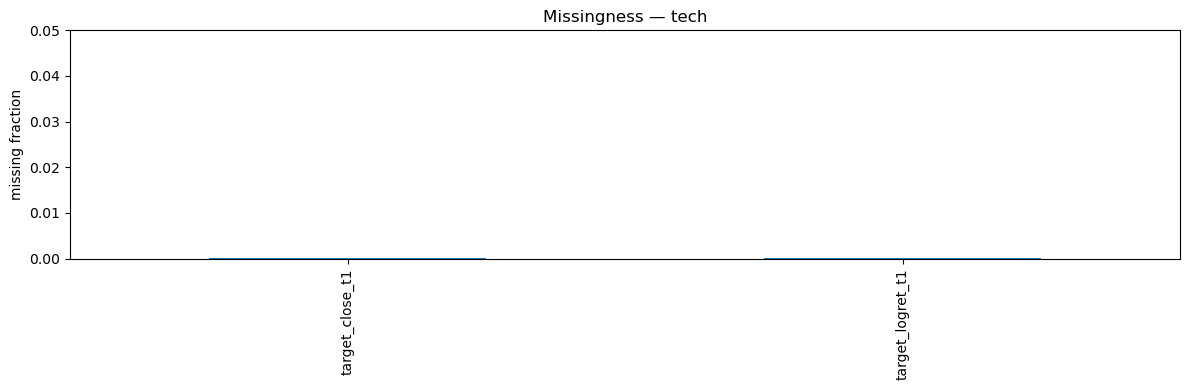

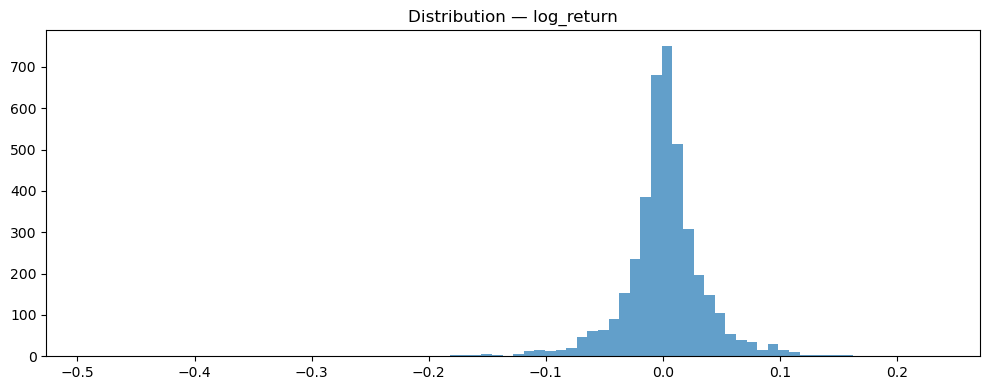

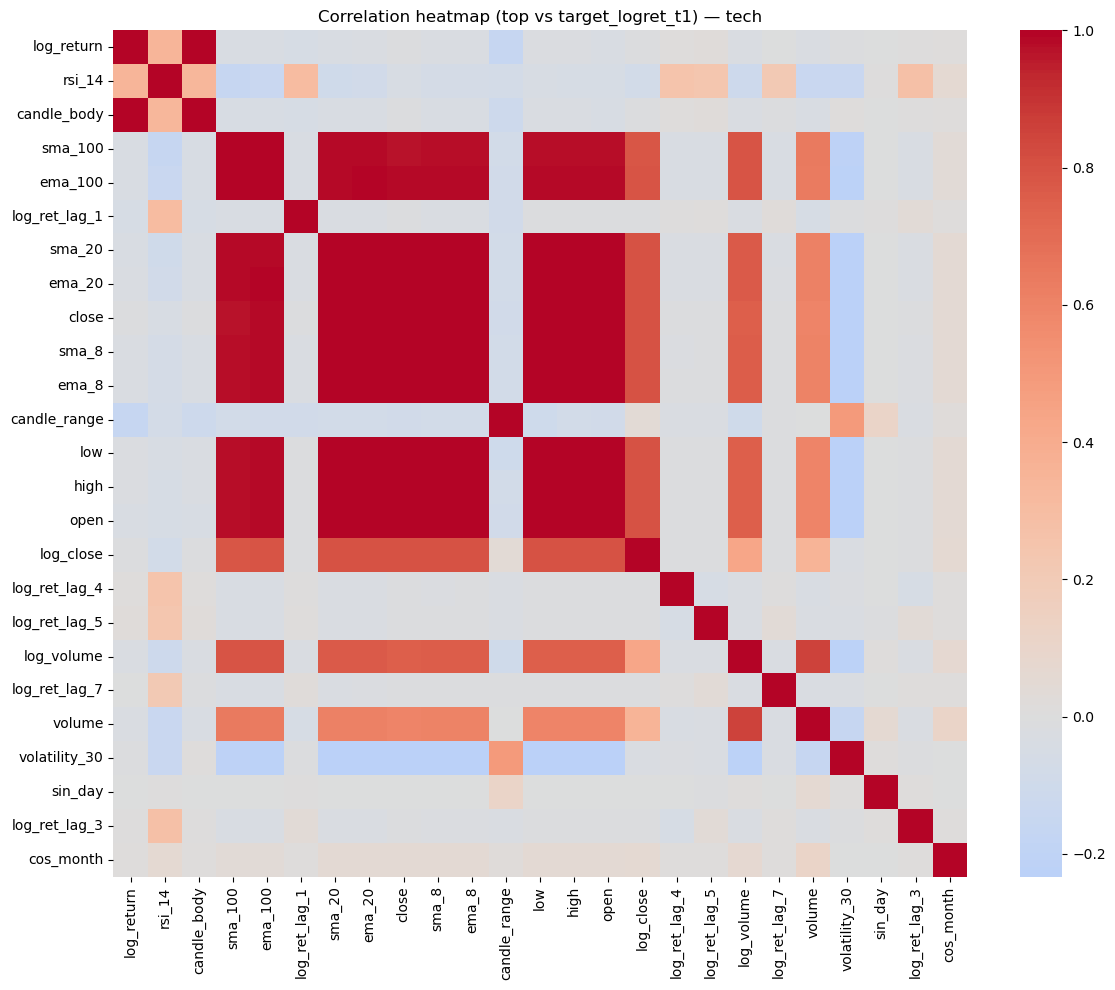

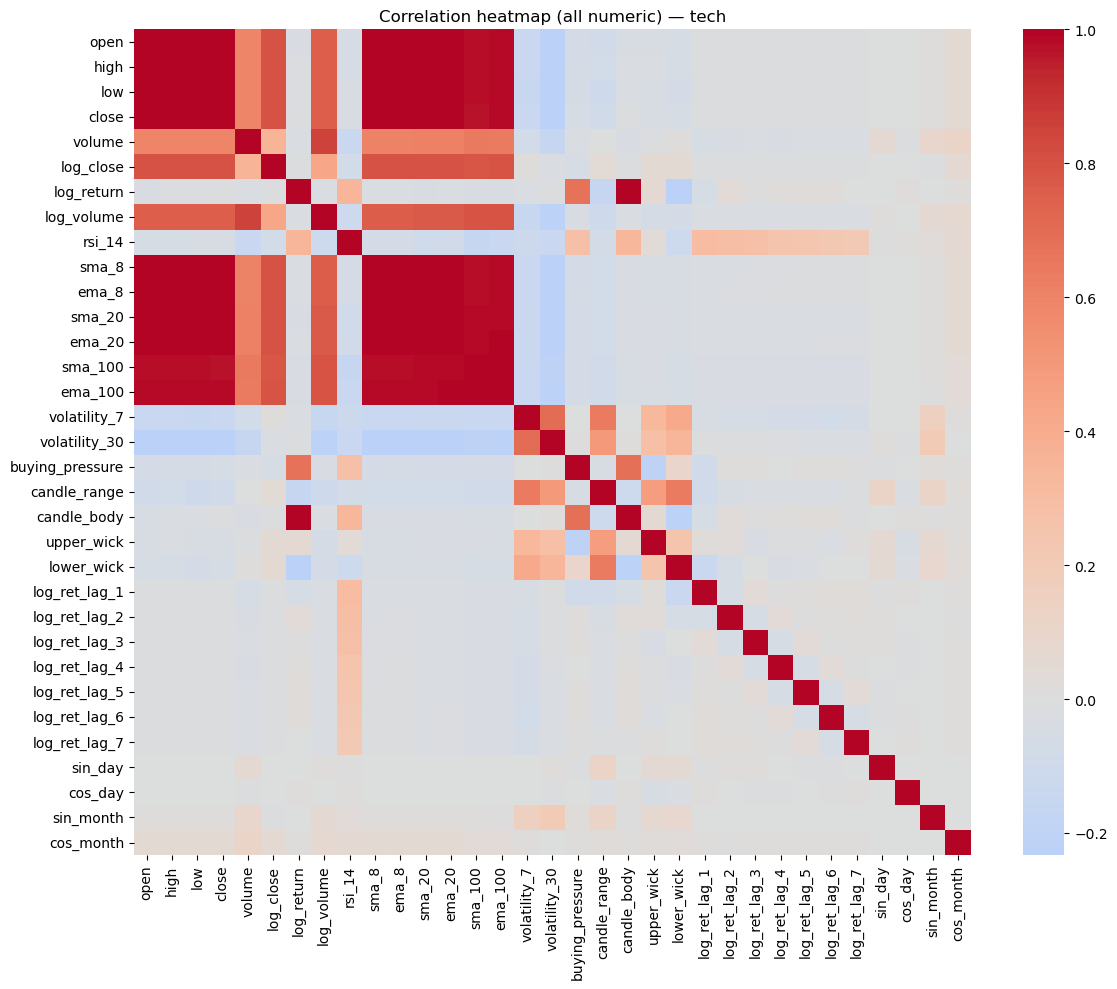

In [4]:
def numeric_cols(df: pd.DataFrame):
    cols = []
    for c in df.columns:
        if c == "timestamp":
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols


def plot_missingness(df: pd.DataFrame, title: str, out_path: pathlib.Path):
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    fig, ax = plt.subplots(figsize=(12, 4))
    if len(miss) == 0:
        ax.text(0.5, 0.5, "No missing values", ha="center", va="center")
        ax.set_axis_off()
    else:
        miss.plot(kind="bar", ax=ax)
        ax.set_ylabel("missing fraction")
        ax.set_ylim(0, min(1.0, float(max(miss.max(), 0.05))))
        ax.set_title(title)
        fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()


def plot_log_return_distribution(df: pd.DataFrame, out_path: pathlib.Path):
    fig, ax = plt.subplots(figsize=(10, 4))
    if "log_return" in df.columns:
        s = df["log_return"].dropna().values
        ax.hist(s, bins=80, alpha=0.7)
        ax.set_title("Distribution — log_return")
    else:
        ax.text(0.5, 0.5, "log_return not found", ha="center", va="center")
        ax.set_axis_off()
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()


def plot_correlation_heatmap(df: pd.DataFrame, cols: list[str], title: str, out_path: pathlib.Path):
    corr = df[cols].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()


def top_abs_corr_with_target(df: pd.DataFrame, target_col: str, exclude: set[str], k: int = 25):
    if target_col not in df.columns:
        return []
    cols = [c for c in numeric_cols(df) if c not in exclude and c != target_col]
    if len(cols) == 0:
        return []
    corr = df[cols + [target_col]].corr(numeric_only=True)[target_col].drop(labels=[target_col], errors="ignore")
    corr = corr.replace([np.inf, -np.inf], np.nan).dropna()
    out = corr.abs().sort_values(ascending=False).head(k)
    return list(out.index)


df_eval = df.copy()
if "log_return" in df_eval.columns:
    df_eval["target_logret_t1"] = df_eval["log_return"].shift(-1)
if "close" in df_eval.columns:
    df_eval["target_close_t1"] = df_eval["close"].shift(-1)

plot_missingness(df_eval, f"Missingness — {FEATURE_SET}", fig_dir / f"{FEATURE_SET}__missingness.png")
plot_log_return_distribution(df_eval, fig_dir / f"{FEATURE_SET}__log_return_hist.png")

base_exclude = {"target_logret_t1", "target_close_t1"}
cols_heat = top_abs_corr_with_target(df_eval, "target_logret_t1", exclude=base_exclude, k=25)
if "log_return" in df_eval.columns:
    cols_heat = ["log_return"] + [c for c in cols_heat if c != "log_return"]
if len(cols_heat) >= 5:
    plot_correlation_heatmap(df_eval.dropna(subset=["target_logret_t1"]).copy(), cols_heat, f"Correlation heatmap (top vs target_logret_t1) — {FEATURE_SET}", fig_dir / f"{FEATURE_SET}__corr_heatmap_top25.png")

cols_all = numeric_cols(df_eval)
cols_all = [c for c in cols_all if c not in ["target_logret_t1", "target_close_t1"]]
if len(cols_all) <= 35 and len(cols_all) >= 5:
    plot_correlation_heatmap(df_eval, cols_all, f"Correlation heatmap (all numeric) — {FEATURE_SET}", fig_dir / f"{FEATURE_SET}__corr_heatmap_all.png")


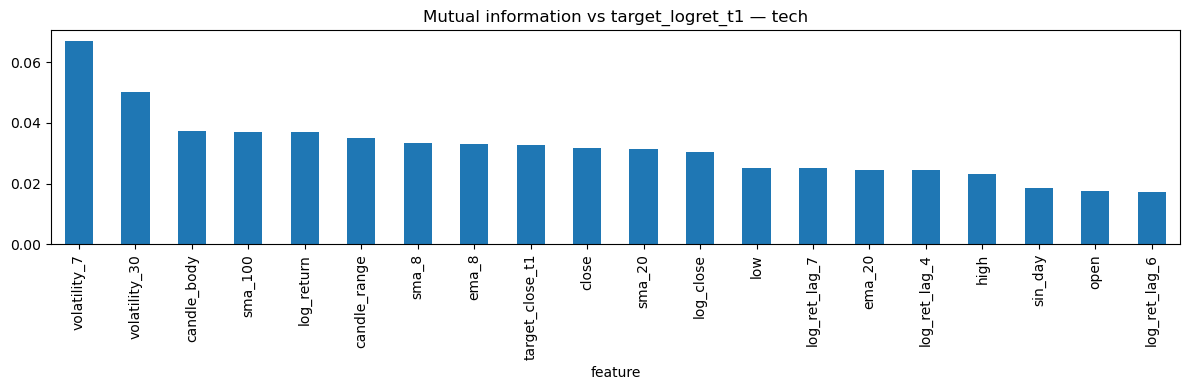

In [5]:
def compute_mi(df: pd.DataFrame, target_col: str, max_features: int = 40):
    df2 = df.dropna(subset=[target_col]).copy()
    cols = [c for c in numeric_cols(df2) if c != target_col]
    cols = cols[:max_features]
    if len(cols) == 0:
        return pd.DataFrame(columns=["feature", "mi"]) 
    X = df2[cols].replace([np.inf, -np.inf], np.nan)
    X = X.fillna(0.0)
    y = df2[target_col].values
    mi = mutual_info_regression(X.values, y, random_state=42)
    out = pd.DataFrame({"feature": cols, "mi": mi}).sort_values("mi", ascending=False)
    return out


if "target_logret_t1" in df_eval.columns:
    mi_df = compute_mi(df_eval, "target_logret_t1", max_features=60)
    fig, ax = plt.subplots(figsize=(12, 4))
    if len(mi_df) > 0:
        mi_df.head(20).set_index("feature")["mi"].plot(kind="bar", ax=ax)
        ax.set_title(f"Mutual information vs target_logret_t1 — {FEATURE_SET}")
        fig.tight_layout()
    else:
        ax.text(0.5, 0.5, "MI not available", ha="center", va="center")
        ax.set_axis_off()
    out_path = fig_dir / f"{FEATURE_SET}__mi_top20.png"
    fig.savefig(out_path, dpi=200)
    plt.show()


In [6]:
rows = []
for fs in FEATURE_SETS:
    p = data_dir / f"btc_1d_features__{fs}.csv"
    if not p.exists():
        continue
    d = load_dataset(p)
    n_rows = int(len(d))
    n_cols = int(d.shape[1])
    start = d["timestamp"].min().isoformat() if n_rows else None
    end = d["timestamp"].max().isoformat() if n_rows else None
    miss_frac = float(d.isna().mean().mean())
    rows.append({"feature_set": fs, "rows": n_rows, "cols": n_cols, "start": start, "end": end, "mean_missing_fraction": miss_frac})

summary = pd.DataFrame(rows).sort_values("feature_set")
summary.to_csv(SUMMARY_PATH, index=False)
summary

,feature_set,rows,cols,start,end,mean_missing_fraction
0,base,4150,9,2014-11-04T00:00:00+00:00,2026-03-15T00:00:00+00:00,0.0
4,full,2961,48,2018-02-01T00:00:00+00:00,2026-03-15T00:00:00+00:00,0.0
2,macro,4144,21,2014-11-10T00:00:00+00:00,2026-03-15T00:00:00+00:00,0.0
3,sent,2961,11,2018-02-01T00:00:00+00:00,2026-03-15T00:00:00+00:00,0.0
1,tech,4052,34,2015-02-10T00:00:00+00:00,2026-03-15T00:00:00+00:00,0.0


In [ ]:
from sklearn.preprocessing import StandardScaler


def export_tfm_feature_matrix_and_corr_full(window_days: int = 365):
    feature_set = "full"
    df_full = load_dataset(data_dir / f"btc_1d_features__{feature_set}.csv")
    cols = numeric_cols(df_full)

    df_win = df_full.tail(int(window_days)).copy()
    X = df_win[cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy()
    Xz = StandardScaler().fit_transform(X)
    Xz = np.clip(Xz, -3.0, 3.0)

    corr = df_full[cols].corr(numeric_only=True)

    fig = plt.figure(figsize=(16, 18))
    gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.35])

    ax1 = fig.add_subplot(gs[0, 0])
    im = ax1.imshow(Xz.T, aspect="auto", cmap="RdBu_r", vmin=-3.0, vmax=3.0)
    ax1.set_title(f"Matriz de características (full) — últimos {window_days} días (z-score)")
    ax1.set_yticks(np.arange(len(cols)))
    ax1.set_yticklabels(cols, fontsize=6)
    ax1.set_xticks([])
    fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.02)

    ax2 = fig.add_subplot(gs[1, 0])
    sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax2, cbar_kws={"shrink": 0.6})
    ax2.set_title("Matriz de correlación (full) — todas las variables numéricas")
    ax2.tick_params(axis="both", labelsize=6)

    fig.tight_layout()

    tfm_fig_dir = (base_dir.parent / "figuras" / "datos").resolve()
    tfm_fig_dir.mkdir(parents=True, exist_ok=True)
    out_path = tfm_fig_dir / "fig_8_4_feature_matrix_corr_full.png"
    fig.savefig(out_path, dpi=200)
    plt.show()
    return out_path


export_tfm_feature_matrix_and_corr_full(window_days=365)